<a href="https://colab.research.google.com/github/abhishekjoshi13/OptimalSafety-Routing/blob/main/OptimalSafety_Routing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random
np.random.seed(42)
num_records = 2000
zones = ['Zone_A', 'Zone_B', 'Zone_C', 'Zone_D', 'Zone_E']
times_of_day = ['Morning', 'Afternoon', 'Evening', 'Late Night']
data = {
    'Zone': [], 'Time_Of_Day': [], 'Working_Streetlights_Pct': [],
    'Distance_To_Police_km': [], 'Num_24x7_Shops': [], 'Recent_Incidents': []
}
for _ in range(num_records):
    zone = random.choice(zones)
    time = random.choice(times_of_day)
    if zone in ['Zone_A', 'Zone_B']:
        police_dist = round(random.uniform(0.5, 2.5), 1)
        shops = random.randint(3, 10)
        streetlights = random.randint(70, 100)
    else:
        police_dist = round(random.uniform(3.0, 8.0), 1)
        shops = random.randint(0, 3)
        streetlights = random.randint(30, 80)
    incident_risk = 0.5
    if time == 'Late Night':
        incident_risk += 2.0
        if streetlights < 50: incident_risk += 3.0
    if police_dist > 5.0: incident_risk += 1.0
    if shops > 5: incident_risk -= 1.0
    incidents = max(0, int(np.random.normal(incident_risk, 1.5)))
    data['Zone'].append(zone)
    data['Time_Of_Day'].append(time)
    data['Working_Streetlights_Pct'].append(streetlights)
    data['Distance_To_Police_km'].append(police_dist)
    data['Num_24x7_Shops'].append(shops)
    data['Recent_Incidents'].append(incidents)
df = pd.DataFrame(data)
max_incidents = df['Recent_Incidents'].max()
df['Safety_Rating_1_to_10'] = 10 - ((df['Recent_Incidents'] / max_incidents) * 9)
df['Safety_Rating_1_to_10'] = df['Safety_Rating_1_to_10'].round(1)
df.to_csv('smart_city_safety_data.csv', index=False)
print("Generated: 'smart_city_safety_data.csv' ")

Generated: 'smart_city_safety_data.csv' 


Training the Smart City model
 Model Accuracy: Predictions are only off by an average of 0.92 points on a 1-10 scale.

 Model is currently evaluating the physical city streets.
 Model Predictions Exported: 'route_data.txt' 



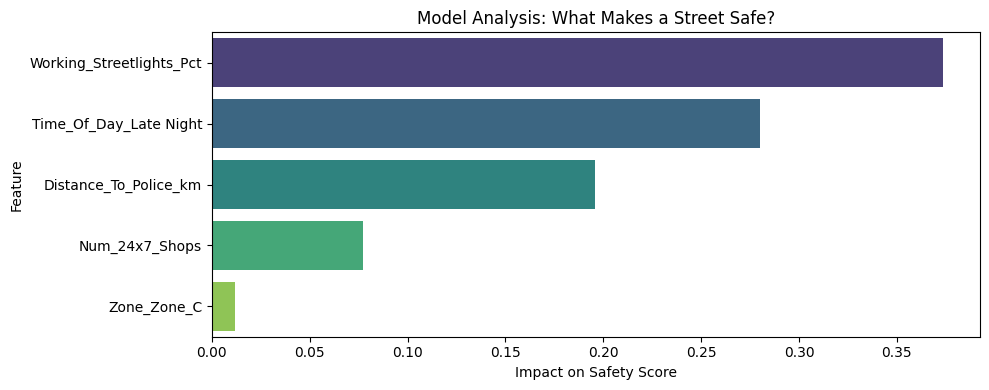

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
df = pd.read_csv('smart_city_safety_data.csv')
X = pd.get_dummies(df.drop(['Recent_Incidents', 'Safety_Rating_1_to_10'], axis=1))
y = df['Safety_Rating_1_to_10']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training the Smart City model")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
error = mean_absolute_error(y_test, predictions)
print(f" Model Accuracy: Predictions are only off by an average of {error:.2f} points on a 1-10 scale.\n")
print(" Model is currently evaluating the physical city streets.")
roads_data = pd.DataFrame([
    {'Start': 0, 'End': 4, 'Distance': 1.5, 'Zone': 'Zone_E', 'Time_Of_Day': 'Late Night', 'Working_Streetlights_Pct': 20, 'Distance_To_Police_km': 7.0, 'Num_24x7_Shops': 0},
    {'Start': 0, 'End': 1, 'Distance': 2.5, 'Zone': 'Zone_A', 'Time_Of_Day': 'Morning', 'Working_Streetlights_Pct': 95, 'Distance_To_Police_km': 1.0, 'Num_24x7_Shops': 8},
    {'Start': 1, 'End': 2, 'Distance': 2.5, 'Zone': 'Zone_A', 'Time_Of_Day': 'Morning', 'Working_Streetlights_Pct': 90, 'Distance_To_Police_km': 1.2, 'Num_24x7_Shops': 7},
    {'Start': 2, 'End': 3, 'Distance': 2.5, 'Zone': 'Zone_B', 'Time_Of_Day': 'Morning', 'Working_Streetlights_Pct': 85, 'Distance_To_Police_km': 1.5, 'Num_24x7_Shops': 6},
    {'Start': 3, 'End': 4, 'Distance': 2.5, 'Zone': 'Zone_B', 'Time_Of_Day': 'Morning', 'Working_Streetlights_Pct': 88, 'Distance_To_Police_km': 1.3, 'Num_24x7_Shops': 9}
])
road_features = roads_data.drop(['Start', 'End', 'Distance'], axis=1)
road_features_encoded = pd.get_dummies(road_features)
road_features_encoded = road_features_encoded.reindex(columns=X.columns, fill_value=0)
roads_data['Model_Safety_Score'] = model.predict(road_features_encoded).round(1)
with open('route_data.txt', 'w') as file:
    for index, row in roads_data.iterrows():
        line = f"{int(row['Start'])} {int(row['End'])} {row['Model_Safety_Score']} {row['Distance']}\n"
        file.write(line)
print(" Model Predictions Exported: 'route_data.txt' \n")
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)
plt.figure(figsize=(10, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue ='Feature', legend = False)
plt.title('Model Analysis: What Makes a Street Safe?')
plt.xlabel('Impact on Safety Score')
plt.tight_layout()
plt.show()

In [4]:
%%writefile safe_route.cpp
#include <iostream>
#include <vector>
#include <queue>
#include <fstream>
#include <algorithm>
using namespace std;
struct Edge {
    int destination;
    double safety_score;
    double physical_distance;
};
void findPracticalSafestPath(int num_intersections, int start_node, int end_node, vector<vector<Edge>>& city_graph) {
    vector<double> min_cost(num_intersections, 1e9);
    vector<int> parent(num_intersections, -1);
    priority_queue<pair<double, int>, vector<pair<double, int>>, greater<pair<double, int>>> pq;
    min_cost[start_node] = 0;
    pq.push({0.0, start_node});
    while (!pq.empty()) {
        double current_cost = pq.top().first;
        int current_node = pq.top().second;
        pq.pop();
        if (current_node == end_node) break;
        if (current_cost > min_cost[current_node]) continue;
        for (auto& road : city_graph[current_node]) {
            int next_node = road.destination;
            double danger_multiplier = 11.0 - road.safety_score;
            double road_cost = road.physical_distance * danger_multiplier;
            double total_path_cost = current_cost + road_cost;
            if (total_path_cost < min_cost[next_node]) {
                min_cost[next_node] = total_path_cost;
                parent[next_node] = current_node;
                pq.push({total_path_cost, next_node});
            }
        }
    }
    vector<int> final_path;
    for (int at = end_node; at != -1; at = parent[at]) {
        final_path.push_back(at);
    }
    reverse(final_path.begin(), final_path.end());
    cout << "   SMART CITY ROUTING COMPLETE\n";
    cout << "Optimal Route (After Balancing Distance & Safety):\n";
    for (size_t i = 0; i < final_path.size(); ++i) {
        cout << final_path[i] << (i == final_path.size() - 1 ? "" : " -> ");
    }
    cout << "\n\n";
}
int main() {
    int total_intersections = 5;
    vector<vector<Edge>> city_map(total_intersections);
    ifstream infile("route_data.txt");
    int start_node, end_node;
    double safety_score, physical_distance;
    if (!infile) {
        cout << "Error: Could not find route_data.txt\n";
        return 1;
    }
    while (infile >> start_node >> end_node >> safety_score >> physical_distance) {
        city_map[start_node].push_back({end_node, safety_score, physical_distance});
    }
    cout << " City Map successfully loaded (with Distances and model Scores).\n";
    cout << " Calculating the most practical safe route from Node 0 to Node 4.\n";
    findPracticalSafestPath(total_intersections, 0, 4, city_map);
    return 0;
}

Writing safe_route.cpp


In [5]:
!g++ safe_route.cpp -o safe_route
!./safe_route

 City Map successfully loaded (with Distances and model Scores).
 Calculating the most practical safe route from Node 0 to Node 4.
   SMART CITY ROUTING COMPLETE
Optimal Route (After Balancing Distance & Safety):
0 -> 4

